notebook creates figures of the cooling / regional temperature annual mean timseries under HiLLA and SSP245 scenarios

In [2]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
from xmip.preprocessing import rename_cmip6
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import json
import cftime
import matplotlib
import warnings
import matplotlib.pyplot as plt
from Utils import get_ds_from_ceda
from Utils import weighted_annual_resample
import seaborn as sns
warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.size': 15})

from HiLLA_utils import get_ds, cut_incomplete_years, spatial_mean, set_time_to_center_of_bounds

# get standard variable names, settings for plotting, region bounds etc. 
from config import models, regions, HiLLA_altitudes, path_archive, ens_mems_arise_UK, ens_mems_CE, colours, model_colors

## read in the arise inj magnitudes, calculated from raw files in "x0_get_ARISE_injs.ipynb"
with open("../intermediate_outputs/arise_inj_mags.json", "r") as f:
    arise_injs = json.load(f)

In [3]:
## UKESM (note the combined run u-dm204dn587 is the 35 year run for 13km 60°)
ds_HiLLA_13_UK = weighted_annual_resample(cut_incomplete_years(get_ds(run = 'u-dm204dn587', var='tas', table='Amon').sel(time=slice(None, '2069'))), var='tas')
ds_HiLLA_15_UK = weighted_annual_resample(cut_incomplete_years(get_ds(run = 'u-dn760', var='tas', table='Amon').sel(time=slice(None, '2069'))), var='tas')

## repeat for CESM
ds_HiLLA_13_CE = weighted_annual_resample(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/Temperature/case01_60NS_13km_MAMJ_6Tg_TREFHT.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069')), var='tas')
ds_HiLLA_15_CE = weighted_annual_resample(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/Temperature/case04_60NS_15km_MAMJ_6Tg_TREFHT.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069')), var='tas')

## repeat for E3SM
ds_HiLLA_13_E3 = weighted_annual_resample(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.01.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069')), var='tas')
ds_HiLLA_15_E3 = weighted_annual_resample(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.04.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069')), var='tas')

## combine into a dict
HiLLA_data = {'UKESM':{'13km':ds_HiLLA_13_UK, '15km':ds_HiLLA_15_UK},
              'CESM':{'13km':ds_HiLLA_13_CE, '15km':ds_HiLLA_15_CE},
              'E3SM':{'13km':ds_HiLLA_13_E3, '15km':ds_HiLLA_15_E3}}

## reduce HiLLA data to annually resampled timeseries
timeseries_dicts_models = []
for model in models:
    timeseries_dicts = []
    for alt in HiLLA_altitudes:
        data = HiLLA_data[model][alt]
        timeseries_dicts.append(dict(zip(regions, [spatial_mean(data, region) for region in regions])))
    
    timeseries_dicts_models.append(dict(zip(HiLLA_altitudes, timeseries_dicts)))

HiLLA_timeseries_dict = dict(zip(models, timeseries_dicts_models))

In [4]:
DS_ssp245_tas_UK = weighted_annual_resample(get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='tas', members=ens_mems_arise_UK, 
                              table='Amon', grid='gn'), var='tas').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})

DS_ssp245_tas_CE = weighted_annual_resample(get_ds_from_ceda(model='CESM2-WACCM', centre='NCAR', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='tas', members=ens_mems_CE, 
                              table='Amon', grid='gn'), var='tas').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})

ds_ssp245_tas_E3 =  xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.control.nc').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'})
ds_ssp245_tas_E3 = weighted_annual_resample(cut_incomplete_years(ds_ssp245_tas_E3), var='tas').sel(time=slice('2015', '2069'))
DS_ssp245_tas_E3 = xr.concat([ds_ssp245_tas_E3], dim='Ensemble_member')
#ds_ssp245_tas_E3['Ensemble_member'] = 'r1'

SSP245_data = {'UKESM':DS_ssp245_tas_UK, 'CESM':DS_ssp245_tas_CE, 'E3SM':DS_ssp245_tas_E3}

## reduce SSP2-4.5 data to annually resampled timeseries
timeseries_dicts = []
for model in models:
    print(model)
    data = SSP245_data[model].load()
    timeseries_dicts.append(dict(zip(regions, [spatial_mean(data, region) for region in regions])))
    
SSP245_timeseries_dict = dict(zip(models, timeseries_dicts))

UKESM
CESM
E3SM


In [5]:
### save cooling maps to intermediate outputs for re-use elsewhere:
for model in models:
    for alt in ['13km', '15km']:
        cooling = HiLLA_data[model][alt] - SSP245_data[model].mean('Ensemble_member')
        cooling.to_netcdf('../intermediate_outputs/cooling_annual/{m}_HiLLA-{a}_cooling.nc'.format(m=model, a=alt))

In [6]:
matplotlib.rcParams.update({'font.size': 15})

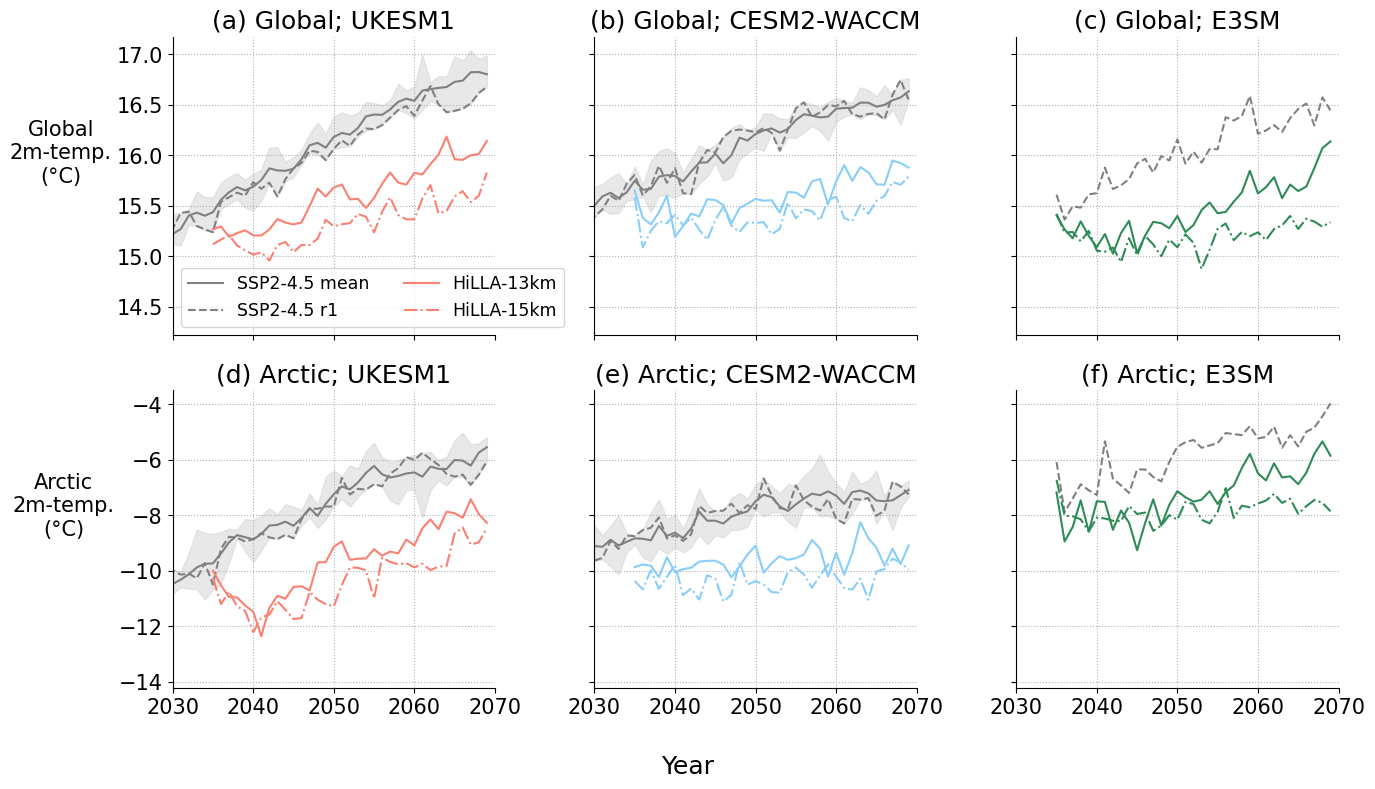

In [7]:
fig, axs = plt.subplots(2, 3, figsize=(14, 8), sharey='row', sharex='col')
t_col = 'black'
alt_linestyles = {'13km':'solid', '15km':'-.'}
kelvinconv = 273.15

piCo_global_dict = {'UKESM':kelvinconv, 'CESM':kelvinconv, 'E3SM':kelvinconv} # fill in with PI values to shift from abs temps to warming
piCo_arctic_dict = {'UKESM':kelvinconv, 'CESM':kelvinconv, 'E3SM':kelvinconv} # fill in with PI values to shift from abs temps to warming


j=0
for model in models:
    i=0
    for region in ['Global', 'Arctic']:
        ax = axs[i, j]
        
        ts_ssp245 = SSP245_timeseries_dict[model][region].tas
        piCo_global = piCo_global_dict[model]
        
        if model in ['UKESM', 'CESM']:
            ax.plot(ts_ssp245.mean('Ensemble_member').time.dt.year.values, (ts_ssp245.mean('Ensemble_member') - piCo_global), c=colours['ssp245'], label='SSP2-4.5 mean')
            ax.fill_between(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, 
                            ts_ssp245.min('Ensemble_member').values - piCo_global, 
                            ts_ssp245.max('Ensemble_member').values - piCo_global, 
                            color=colours['ssp245_light'], alpha=0.5)
        ax.plot(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, (ts_ssp245.isel(Ensemble_member=0) - piCo_global), c=colours['ssp245'], ls='--', label='SSP2-4.5 r1')
        for alt in HiLLA_altitudes:
            HiLLA = HiLLA_timeseries_dict[model][alt][region]
            ax.plot(HiLLA.time.dt.year,(HiLLA.tas - piCo_global),
            c=model_colors[model], ls= alt_linestyles[alt], label='HiLLA-{}'.format(alt))
            
        ax.grid(ls='dotted')
        if region == 'Global':
            if model == 'UKESM':
                ax.legend(fontsize='small', ncols=2)
        i=i+1
    j=j+1

for ax in axs.flatten():
    ax.set_xlim(2030, 2070)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('')
    ax.set_xlabel('')

axs[0, 0].set_title('(a) Global; UKESM1')
axs[0, 1].set_title('(b) Global; CESM2-WACCM')
axs[0, 2].set_title('(c) Global; E3SM')
axs[1, 0].set_title('(d) Arctic; UKESM1')
axs[1, 1].set_title('(e) Arctic; CESM2-WACCM')
axs[1, 2].set_title('(f) Arctic; E3SM')


axs[0, 0].set_ylabel('Global\n2m-temp.\n(°C)', rotation=0, labelpad=40)
axs[1, 0].set_ylabel('Arctic\n2m-temp.\n(°C)', rotation=0, labelpad=40)

fig.supxlabel('Year')

plt.tight_layout()
plt.savefig('Figures/tas_summary.jpg', dpi=300)

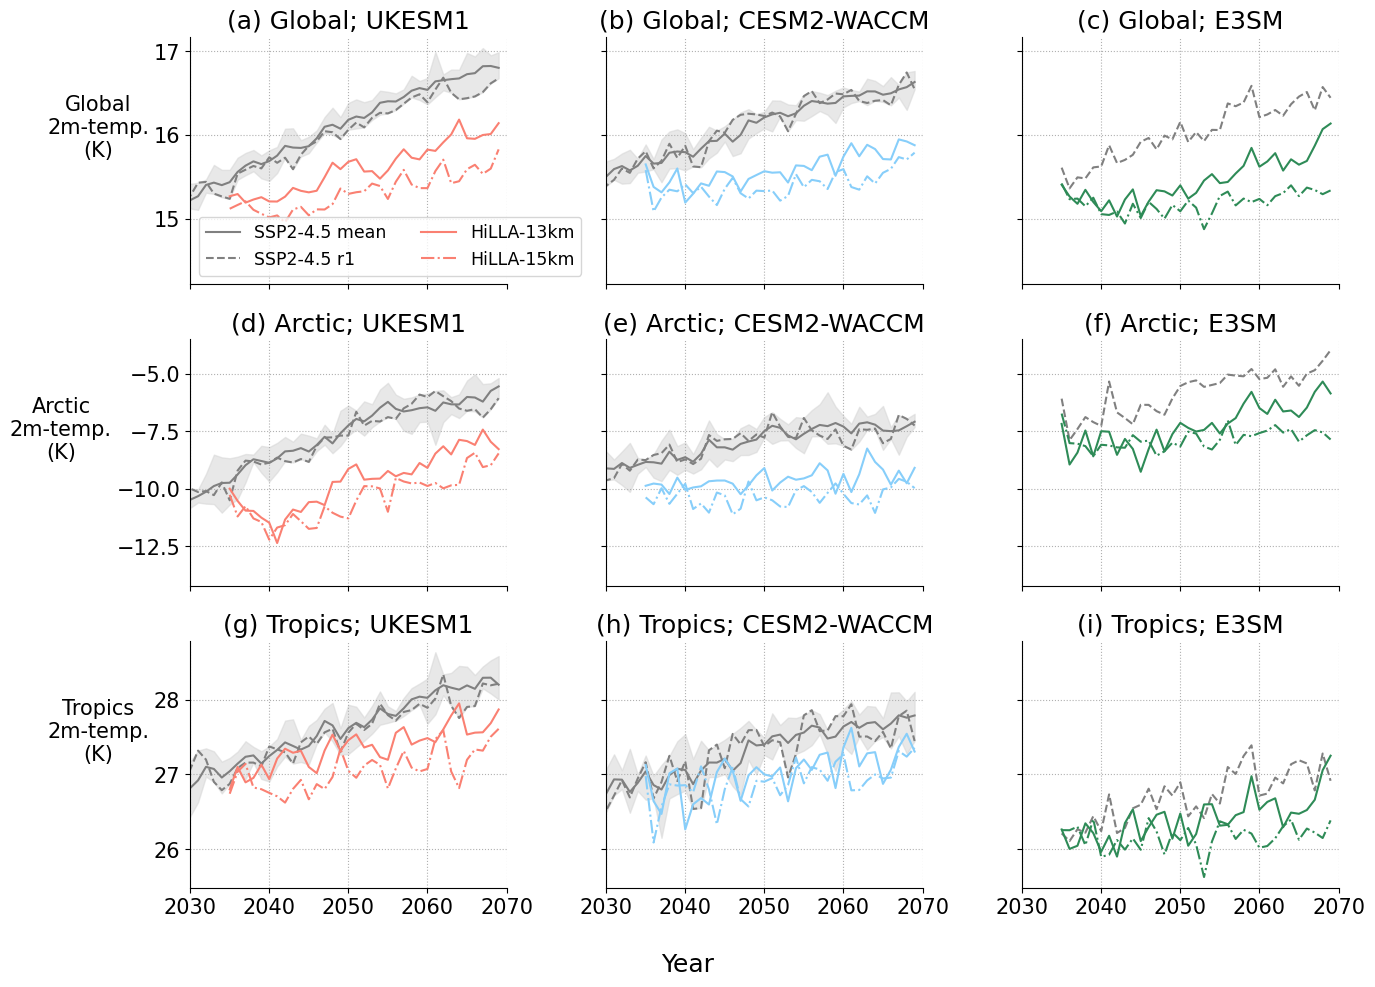

In [8]:
fig, axs = plt.subplots(3, 3, figsize=(14, 10), sharey='row', sharex='col')
t_col = 'black'
alt_linestyles = {'13km':'solid', '15km':'-.'}

piCo_global_dict = {'UKESM':kelvinconv, 'CESM':kelvinconv, 'E3SM':kelvinconv} # fill in with PI values to shift from abs temps to warming
piCo_arctic_dict = {'UKESM':kelvinconv, 'CESM':kelvinconv, 'E3SM':kelvinconv} # fill in with PI values to shift from abs temps to warming


j=0
for model in models:
    i=0
    for region in ['Global', 'Arctic', 'Tropics']:
        ax = axs[i, j]
        
        ts_ssp245 = SSP245_timeseries_dict[model][region].tas
        piCo_global = piCo_global_dict[model]
        
        if model in ['UKESM', 'CESM']:
            ax.plot(ts_ssp245.mean('Ensemble_member').time.dt.year.values, (ts_ssp245.mean('Ensemble_member') - piCo_global), c=colours['ssp245'], label='SSP2-4.5 mean')
            ax.fill_between(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, 
                            ts_ssp245.min('Ensemble_member').values - piCo_global, 
                            ts_ssp245.max('Ensemble_member').values - piCo_global, 
                            color=colours['ssp245_light'], alpha=0.5)
        ax.plot(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, (ts_ssp245.isel(Ensemble_member=0) - piCo_global), c=colours['ssp245'], ls='--', label='SSP2-4.5 r1')
        for alt in HiLLA_altitudes:
            HiLLA = HiLLA_timeseries_dict[model][alt][region]
            ax.plot(HiLLA.time.dt.year,(HiLLA.tas - piCo_global),
            c=model_colors[model], ls= alt_linestyles[alt], label='HiLLA-{}'.format(alt))
            
        ax.grid(ls='dotted')
        if region == 'Global':
            if model == 'UKESM':
                ax.legend(fontsize='small', ncols=2)
        i=i+1
    j=j+1

for ax in axs.flatten():
    ax.set_xlim(2030, 2070)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('')
    ax.set_xlabel('')

axs[0, 0].set_title('(a) Global; UKESM1')
axs[0, 1].set_title('(b) Global; CESM2-WACCM')
axs[0, 2].set_title('(c) Global; E3SM')
axs[1, 0].set_title('(d) Arctic; UKESM1')
axs[1, 1].set_title('(e) Arctic; CESM2-WACCM')
axs[1, 2].set_title('(f) Arctic; E3SM')
axs[2, 0].set_title('(g) Tropics; UKESM1')
axs[2, 1].set_title('(h) Tropics; CESM2-WACCM')
axs[2, 2].set_title('(i) Tropics; E3SM')


axs[0, 0].set_ylabel('Global\n2m-temp.\n(K)', rotation=0, labelpad=40)
axs[1, 0].set_ylabel('Arctic\n2m-temp.\n(K)', rotation=0, labelpad=40)
axs[2, 0].set_ylabel('Tropics\n2m-temp.\n(K)', rotation=0, labelpad=40)

fig.supxlabel('Year')

plt.tight_layout()
plt.savefig('Figures/tas_summary_with_tropics.jpg', dpi=300)

In [10]:
import scipy

# print the AA ratio for the three models:
for model in models:
    ts_ssp245_global = SSP245_timeseries_dict[model]['Global'].mean('Ensemble_member').tas
    lr_global = scipy.stats.linregress(ts_ssp245_global.time.dt.year.values, ts_ssp245_global.values).slope

    ts_ssp245_arctic = SSP245_timeseries_dict[model]['Arctic'].mean('Ensemble_member').tas
    lr_arctic = scipy.stats.linregress(ts_ssp245_arctic.time.dt.year.values, ts_ssp245_arctic.values).slope

    print(model, lr_global, lr_arctic, lr_arctic/lr_global)

UKESM 0.04495670889132542 0.1418553299349646 3.1553762148798254
CESM 0.02973324308912759 0.05209927348332151 1.752223036254407
E3SM 0.03080569988316019 0.07986368566394149 2.592497036809693


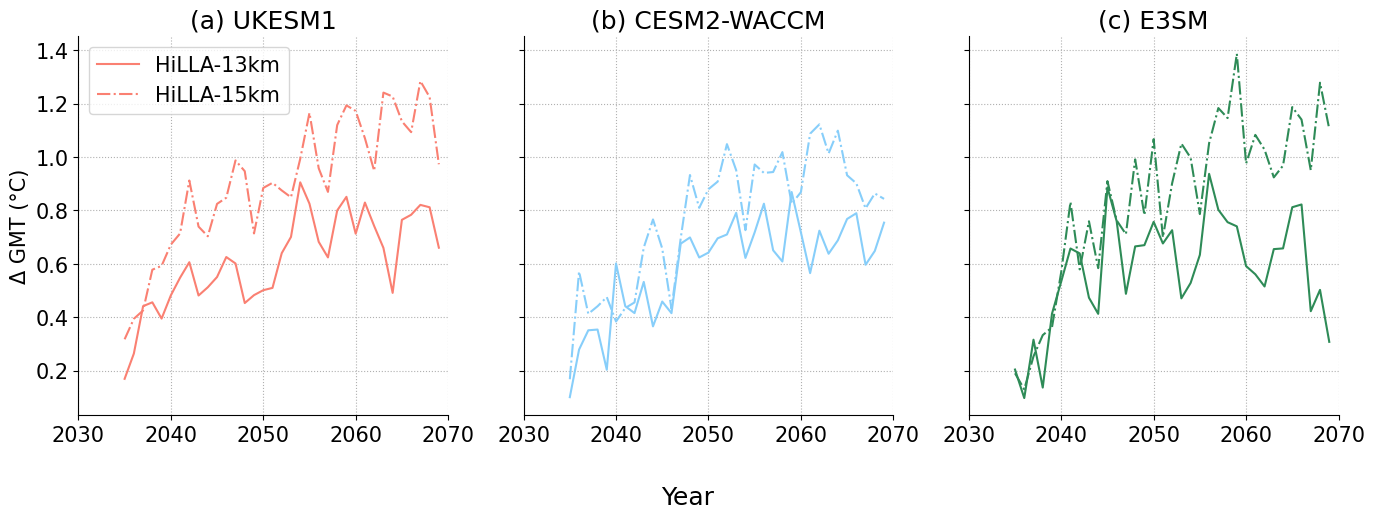

In [12]:
### show cooling mag evolutions: 


region = 'Global'

HiLLA_cooling_ts = SSP245_timeseries_dict[model][region].tas - HiLLA_timeseries_dict[model][alt][region].tas


fig, axs = plt.subplots(1, 3, figsize=(14, 5), sharey='row', sharex='col')
t_col = 'black'
alt_linestyles = {'13km':'solid', '15km':'-.'}

i=0
for model in models:
    ax = axs[i]

    for alt in ['13km', '15km']:
        HiLLA_cooling_ts = (SSP245_timeseries_dict[model][region].tas - HiLLA_timeseries_dict[model][alt][region].tas).mean('Ensemble_member')
        ax.plot(HiLLA_cooling_ts.time.dt.year,HiLLA_cooling_ts,
                c=model_colors[model], ls= alt_linestyles[alt], label='HiLLA-{}'.format(alt))
            
        ax.grid(ls='dotted')
    i=i+1

    ax.set_xlim(2030, 2070)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('')
    ax.set_xlabel('')

axs[0].legend()
fig.supxlabel('Year')
axs[0].set_ylabel('\u0394 GMT (°C)')
plt.tight_layout()

axs[0].set_title('(a) UKESM1')
axs[1].set_title('(b) CESM2-WACCM')
axs[2].set_title('(c) E3SM')

plt.savefig('Figures/cooling_evolution_summary.jpg', dpi=300, bbox_inches='tight')